# Task 6: K-Nearest Neighbors (KNN) Classification

## Objective
Implement KNN Classification using the Iris Dataset and evaluate performance using multiple K values.

### Tasks Performed
- Data Loading
- Data Exploration
- Feature Scaling
- KNN Classification
- K Value Comparison
- Confusion Matrix
- Classification Report
- Decision Boundary Visualization
- Model Evaluation

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from matplotlib.colors import ListedColormap

pd.set_option("display.max_columns", None)

In [2]:
print("="*70)
print("LOADING IRIS DATASET")
print("="*70)

df = pd.read_csv("Iris.csv")

print("\nDataset Shape :", df.shape)

display(df.head())

LOADING IRIS DATASET

Dataset Shape : (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
print("="*70)
print("DATASET INFORMATION")
print("="*70)

df.info()

print("\nMissing Values")
print(df.isnull().sum())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Missing Values
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [4]:
display(df.describe())

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


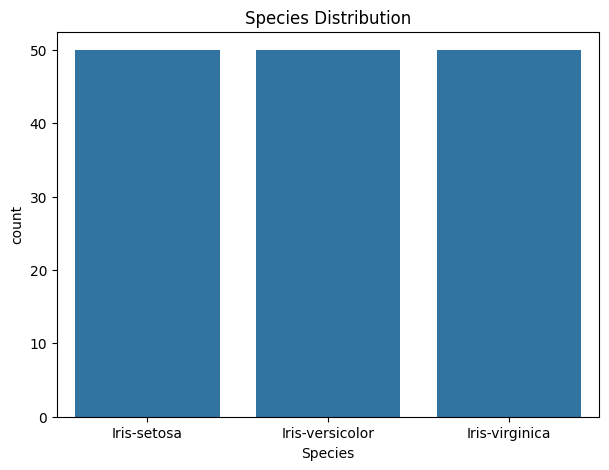

In [5]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Species',
    data=df
)

plt.title("Species Distribution")

plt.show()

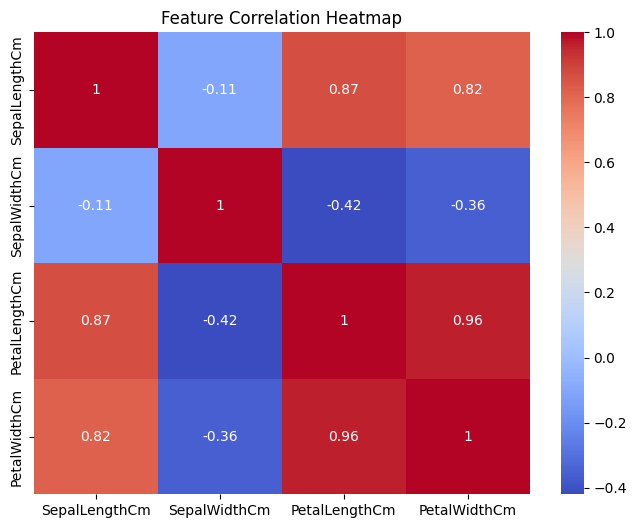

In [6]:
numeric_df = df.drop(
    columns=["Id","Species"]
)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [7]:
X = df[[
    'SepalLengthCm',
    'PetalLengthCm'
]]

y = df['Species']

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (150, 2)
Target Shape   : (150,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 120
Testing Samples  : 30


In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


In [10]:
k_values = range(1,21)

accuracies = []

for k in k_values:

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(X_test)

    acc = accuracy_score(
        y_test,
        pred
    )

    accuracies.append(acc)

print("K Value Testing Completed")

K Value Testing Completed


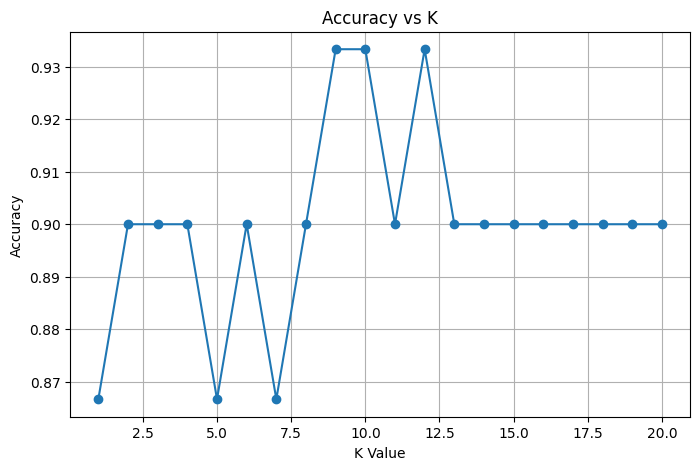

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    accuracies,
    marker='o'
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")

plt.title("Accuracy vs K")

plt.grid()

plt.show()

In [12]:
best_k = k_values[
    np.argmax(accuracies)
]

best_accuracy = max(accuracies)

print("Best K :", best_k)
print("Best Accuracy :", round(best_accuracy,4))

Best K : 9
Best Accuracy : 0.9333


In [13]:
knn = KNeighborsClassifier(
    n_neighbors=best_k
)

knn.fit(
    X_train,
    y_train
)

y_pred = knn.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Final Accuracy :", round(accuracy,4))

Final Accuracy : 0.9333


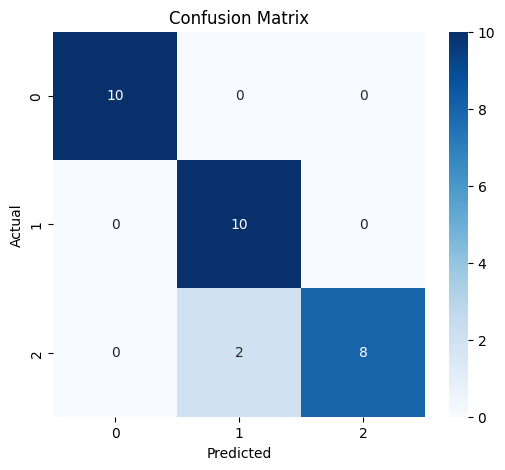

In [14]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [15]:
print(classification_report(
    y_test,
    y_pred
))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



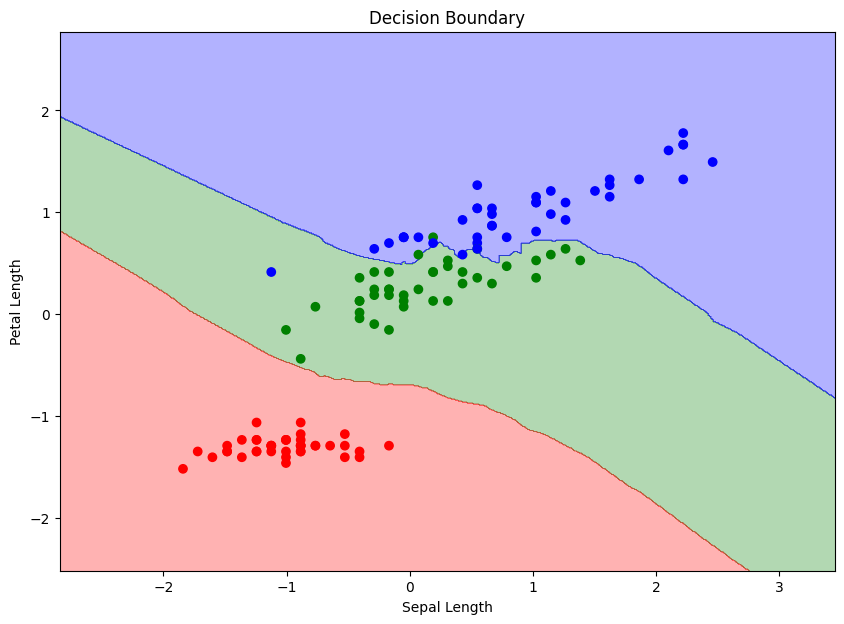

In [16]:
X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(
        start=X_set[:,0].min()-1,
        stop=X_set[:,0].max()+1,
        step=0.01
    ),
    np.arange(
        start=X_set[:,1].min()-1,
        stop=X_set[:,1].max()+1,
        step=0.01
    )
)

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y_train)

knn.fit(X_train,y_encoded)

plt.figure(figsize=(10,7))

plt.contourf(
    X1,
    X2,
    knn.predict(
        np.array(
            [X1.ravel(), X2.ravel()]
        ).T
    ).reshape(X1.shape),
    alpha=0.3,
    cmap=ListedColormap(
        ('red','green','blue')
    )
)

plt.scatter(
    X_train[:,0],
    X_train[:,1],
    c=y_encoded,
    cmap=ListedColormap(
        ('red','green','blue')
    )
)

plt.title("Decision Boundary")
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")

plt.show()

In [17]:
print("\n")
print("="*70)
print("TASK 6 : KNN CLASSIFICATION COMPLETED")
print("="*70)

print("\nDataset Used      : Iris Dataset")
print("Total Records     :", len(df))
print("Total Features    :", X.shape[1])

print("\nBest K Value      :", best_k)
print("Model Accuracy    :", round(accuracy,4))

print("\nOperations Performed")

print("✓ Data Loading")
print("✓ Data Exploration")
print("✓ Missing Value Analysis")
print("✓ Feature Scaling")
print("✓ KNN Classification")
print("✓ K Value Experimentation")
print("✓ Confusion Matrix")
print("✓ Classification Report")
print("✓ Decision Boundary Visualization")
print("✓ Model Evaluation")

print("\nModel Successfully Built and Evaluated")



TASK 6 : KNN CLASSIFICATION COMPLETED

Dataset Used      : Iris Dataset
Total Records     : 150
Total Features    : 2

Best K Value      : 9
Model Accuracy    : 0.9333

Operations Performed
✓ Data Loading
✓ Data Exploration
✓ Missing Value Analysis
✓ Feature Scaling
✓ KNN Classification
✓ K Value Experimentation
✓ Confusion Matrix
✓ Classification Report
✓ Decision Boundary Visualization
✓ Model Evaluation

Model Successfully Built and Evaluated
